# Freddie Mac Mortgage Risk Project
## Notebook 03: Exploratory Analysis and Feature Preparation

This notebook explores the origination-stage modeling base created in Notebook 02. The objective is to validate the 12-month serious delinquency target, assess feature quality, review missingness and segment-level risk patterns, and prepare the dataset for predictive modeling.

## 1. Import packages and define project paths

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

BASE = Path("/content/drive/MyDrive/freddie_mac_risk_project")
PROCESSED = BASE / "data" / "processed"
TABLES = BASE / "outputs" / "tables"
FIGS = BASE / "outputs" / "figures"

print("Processed path exists:", PROCESSED.exists())
print("Tables path exists:", TABLES.exists())
print("Figures path exists:", FIGS.exists())

Mounted at /content/drive
Processed path exists: True
Tables path exists: True
Figures path exists: True


## 2. Load the modeling base

In [2]:
modeling_base = pd.read_parquet(PROCESSED / "modeling_base_with_target_2019_2023.parquet")

print("Modeling base shape:", modeling_base.shape)
modeling_base.head()

Modeling base shape: (250000, 34)


,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_pct,num_units,occupancy_status,cltv,dti,...,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,relief_refinance_indicator,property_valuation_method,interest_only_indicator,mi_cancellation_indicator,vintage_year,target_12m_serious_dq
0,741,2019-03-01,N,2049-02-01,None,0,1,P,80,33,...,Other servicers,None,None,9,None,7,N,7,2019,0
1,731,2019-03-01,N,2049-02-01,13460,0,1,P,77,44,...,Other servicers,None,None,9,None,7,N,7,2019,0
2,722,2019-03-01,N,2049-02-01,None,30,1,P,95,41,...,Other servicers,None,None,9,None,7,N,N,2019,0
3,729,2019-03-01,N,2049-02-01,None,25,1,P,87,17,...,Other servicers,None,None,9,None,7,N,N,2019,0
4,773,2019-03-01,N,2049-02-01,33700,0,1,P,29,43,...,Other servicers,None,None,9,None,7,N,7,2019,0


## 3. Confirm target distribution and dataset structure

In [3]:
print("Column count:", modeling_base.shape[1])
print("\nDtypes preview:")
print(modeling_base.dtypes.head(15))

target_distribution = modeling_base["target_12m_serious_dq"].value_counts(dropna=False).sort_index()
target_rate = modeling_base["target_12m_serious_dq"].mean()

print("\nTarget distribution:")
print(target_distribution)

print("\nTarget rate:", target_rate)

Column count: 34

Dtypes preview:
credit_score                          int64
first_payment_date           datetime64[ns]
first_time_homebuyer_flag            object
maturity_date                datetime64[ns]
msa                                  object
mi_pct                                int64
num_units                             int64
occupancy_status                     object
cltv                                  int64
dti                                   int64
original_upb                          int64
ltv                                   int64
interest_rate                       float64
channel                              object
prepayment_penalty_flag              object
dtype: object

Target distribution:
target_12m_serious_dq
0    247394
1      2606
Name: count, dtype: int64

Target rate: 0.010424


## 4. Review event rate by vintage year

In [4]:
event_rate_by_vintage = (
    modeling_base.groupby("vintage_year")["target_12m_serious_dq"]
    .agg(["count", "mean"])
    .rename(columns={"count": "loan_count", "mean": "event_rate"})
    .reset_index()
)

event_rate_by_vintage

,vintage_year,loan_count,event_rate
0,2019,50000,0.02324
1,2020,50000,0.01176
2,2021,50000,0.00394
3,2022,50000,0.00700
4,2023,50000,0.00618


## 5. Review missingness across the modeling base


In [5]:
missingness = (
    modeling_base.isna().mean()
    .sort_values(ascending=False)
    .reset_index()
)

missingness.columns = ["column", "missing_rate"]
missingness.head(20)

,column,missing_rate
0,relief_refinance_indicator,0.999880
1,pre_harp_loan_sequence_number,0.999880
2,super_conforming_flag,0.971372
3,msa,0.092748
4,first_payment_date,0.000000
5,credit_score,0.000000
6,num_units,0.000000
7,first_time_homebuyer_flag,0.000000
8,maturity_date,0.000000
9,mi_pct,0.000000


## 6. Select candidate modeling features for first-pass review

In [6]:
candidate_features = [
    "credit_score",
    "first_time_homebuyer_flag",
    "msa",
    "mi_pct",
    "num_units",
    "occupancy_status",
    "cltv",
    "dti",
    "original_upb",
    "ltv",
    "interest_rate",
    "channel",
    "property_state",
    "property_type",
    "postal_code",
    "loan_purpose",
    "original_loan_term",
    "num_borrowers",
    "seller_name",
    "servicer_name",
    "super_conforming_flag",
    "program_indicator",
    "relief_refinance_indicator",
    "property_valuation_method",
    "interest_only_indicator",
    "mi_cancellation_indicator"
]

feature_missingness = (
    modeling_base[candidate_features].isna().mean()
    .sort_values(ascending=False)
    .reset_index()
)

feature_missingness.columns = ["feature", "missing_rate"]
feature_missingness

,feature,missing_rate
0,relief_refinance_indicator,0.999880
1,super_conforming_flag,0.971372
2,msa,0.092748
3,mi_pct,0.000000
4,first_time_homebuyer_flag,0.000000
5,occupancy_status,0.000000
6,cltv,0.000000
7,dti,0.000000
8,num_units,0.000000
9,credit_score,0.000000


## 7. Review event rate by key business features


In [7]:
credit_score_bins = pd.cut(
    modeling_base["credit_score"],
    bins=[0, 620, 680, 740, 800, 900],
    right=False
)

credit_score_risk = (
    modeling_base.groupby(credit_score_bins)["target_12m_serious_dq"]
    .agg(["count", "mean"])
    .rename(columns={"count": "loan_count", "mean": "event_rate"})
    .reset_index()
)

ltv_bins = pd.cut(
    modeling_base["ltv"],
    bins=[0, 60, 80, 90, 100, 200],
    right=False
)

ltv_risk = (
    modeling_base.groupby(ltv_bins)["target_12m_serious_dq"]
    .agg(["count", "mean"])
    .rename(columns={"count": "loan_count", "mean": "event_rate"})
    .reset_index()
)

dti_bins = pd.cut(
    modeling_base["dti"],
    bins=[0, 20, 30, 40, 50, 100],
    right=False
)

dti_risk = (
    modeling_base.groupby(dti_bins)["target_12m_serious_dq"]
    .agg(["count", "mean"])
    .rename(columns={"count": "loan_count", "mean": "event_rate"})
    .reset_index()
)

print("Credit score risk:")
display(credit_score_risk)

print("LTV risk:")
display(ltv_risk)

print("DTI risk:")
display(dti_risk)

Credit score risk:


/tmp/ipykernel_171/1959468985.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  modeling_base.groupby(credit_score_bins)["target_12m_serious_dq"]
/tmp/ipykernel_171/1959468985.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  modeling_base.groupby(ltv_bins)["target_12m_serious_dq"]
/tmp/ipykernel_171/1959468985.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  modeling_base.groupby(dti_bins)["target_12m_serious_d

,credit_score,loan_count,event_rate
0,"[0, 620)",222,0.031532
1,"[620, 680)",19552,0.025829
2,"[680, 740)",70956,0.015573
3,"[740, 800)",128399,0.007017
4,"[800, 900)",30819,0.002823


LTV risk:


,ltv,loan_count,event_rate
0,"[0, 60)",52726,0.006221
1,"[60, 80)",80395,0.009652
2,"[80, 90)",58267,0.010847
3,"[90, 100)",58610,0.014827
4,"[100, 200)",2,0.500000


DTI risk:


,dti,loan_count,event_rate
0,"[0, 20)",16805,0.003630
1,"[20, 30)",51073,0.005815
2,"[30, 40)",80545,0.009485
3,"[40, 50)",92657,0.014721
4,"[50, 100)",8879,0.013402


## 8. Save first-pass EDA summaries

In [8]:
event_rate_by_vintage.to_csv(TABLES / "eda_event_rate_by_vintage.csv", index=False)
missingness.to_csv(TABLES / "eda_missingness_all_columns.csv", index=False)
feature_missingness.to_csv(TABLES / "eda_candidate_feature_missingness.csv", index=False)
credit_score_risk.to_csv(TABLES / "eda_credit_score_risk.csv", index=False)
ltv_risk.to_csv(TABLES / "eda_ltv_risk.csv", index=False)
dti_risk.to_csv(TABLES / "eda_dti_risk.csv", index=False)

print(TABLES / "eda_event_rate_by_vintage.csv")
print(TABLES / "eda_missingness_all_columns.csv")
print(TABLES / "eda_candidate_feature_missingness.csv")
print(TABLES / "eda_credit_score_risk.csv")
print(TABLES / "eda_ltv_risk.csv")
print(TABLES / "eda_dti_risk.csv")

/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_event_rate_by_vintage.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_missingness_all_columns.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_candidate_feature_missingness.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_credit_score_risk.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_ltv_risk.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_dti_risk.csv


## Conclusion

The modeling base has been loaded successfully, the target distribution has been validated, and the first round of exploratory analysis has identified basic missingness patterns and segment-level differences in delinquency risk. These results will guide feature selection, preprocessing choices, and model design in the next phase.

## Note: focused visual EDA

The first-pass tabular EDA confirmed that the modeling base is structurally sound and that key underwriting variables behave directionally as expected. The next step is to add a small number of focused visualizations that support business interpretation, validate the target further, and highlight how serious delinquency varies across key origination dimensions. Each chart will be followed by a short analytical note to make the findings presentation-ready.

## 10. Import plotting libraries

In [9]:
import matplotlib.pyplot as plt

## 11. Plot target distribution


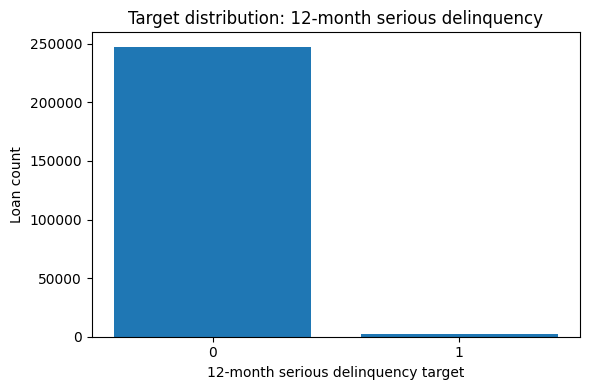

In [10]:
target_plot = modeling_base["target_12m_serious_dq"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_plot.index.astype(str), target_plot.values)
plt.xlabel("12-month serious delinquency target")
plt.ylabel("Loan count")
plt.title("Target distribution: 12-month serious delinquency")
plt.tight_layout()
plt.show()

The target is highly imbalanced, with non-events representing the vast majority of loans and serious delinquency affecting only a small share of the portfolio. This is consistent with the earlier tabular review and confirms that the modeling problem is a low-event credit-risk classification task. From a modeling perspective, this means later steps should account for class imbalance when evaluating performance and selecting decision thresholds.

## 12. Plot event rate by vintage year

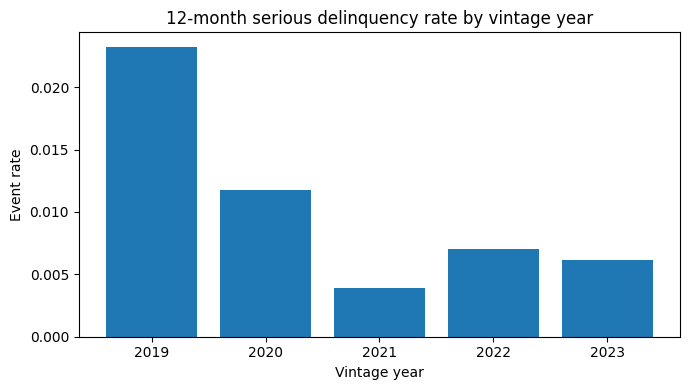

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(event_rate_by_vintage["vintage_year"].astype(str), event_rate_by_vintage["event_rate"])
plt.xlabel("Vintage year")
plt.ylabel("Event rate")
plt.title("12-month serious delinquency rate by vintage year")
plt.tight_layout()
plt.show()

The delinquency rate varies materially across origination vintages, indicating that cohort effects are present in the portfolio. The pattern is not strictly monotonic, with 2019 showing the highest first-year serious delinquency rate, 2021 showing the lowest, and 2022–2023 rising modestly relative to 2021. This suggests that underwriting conditions, borrower mix, and broader economic context may differ across origination cohorts. For modeling purposes, this reinforces the importance of preserving temporal structure in validation rather than relying only on random splits.

## 13. Plot event rate by credit score band

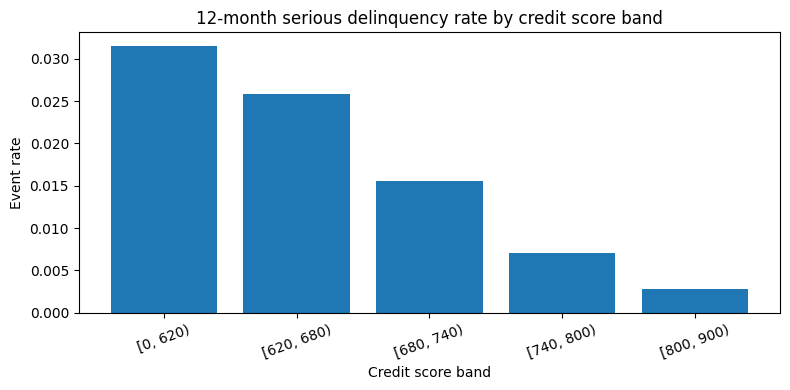

In [12]:
plt.figure(figsize=(8, 4))
plt.bar(credit_score_risk["credit_score"].astype(str), credit_score_risk["event_rate"])
plt.xticks(rotation=20)
plt.xlabel("Credit score band")
plt.ylabel("Event rate")
plt.title("12-month serious delinquency rate by credit score band")
plt.tight_layout()
plt.show()

The event rate declines steadily as credit score increases, which is exactly what we would expect in a mortgage underwriting setting. Lower-score borrowers show materially higher 12-month serious delinquency rates, while the highest-score band has the lowest observed risk. This is one of the strongest early validations that the target behaves like a genuine credit-risk outcome rather than a noisy or misaligned label.

## 14. Plot event rate by loan-to-value band

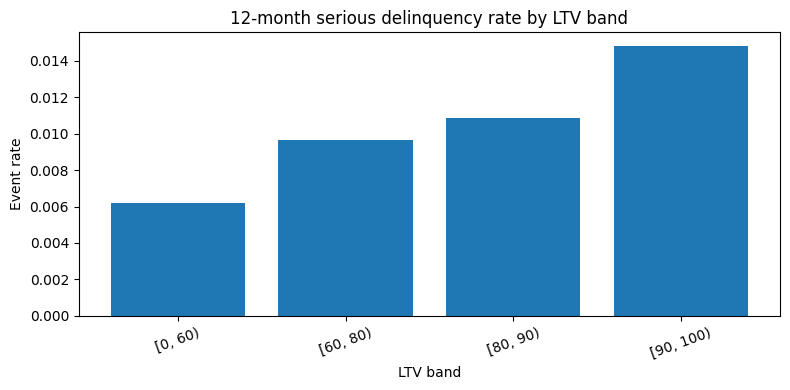

In [13]:
ltv_plot = ltv_risk.copy()
ltv_plot = ltv_plot[ltv_plot["loan_count"] >= 100]  # remove tiny unstable buckets

plt.figure(figsize=(8, 4))
plt.bar(ltv_plot["ltv"].astype(str), ltv_plot["event_rate"])
plt.xticks(rotation=20)
plt.xlabel("LTV band")
plt.ylabel("Event rate")
plt.title("12-month serious delinquency rate by LTV band")
plt.tight_layout()
plt.show()

The event rate rises as loan-to-value increases, indicating that more highly leveraged borrowers tend to exhibit higher early delinquency risk. This pattern is consistent with mortgage credit intuition: loans originated with less borrower equity tend to carry higher vulnerability. The smallest extreme-LTV bucket was excluded from the chart because its sample size was too small to support a stable interpretation.

## 15. Plot event rate by debt-to-income band

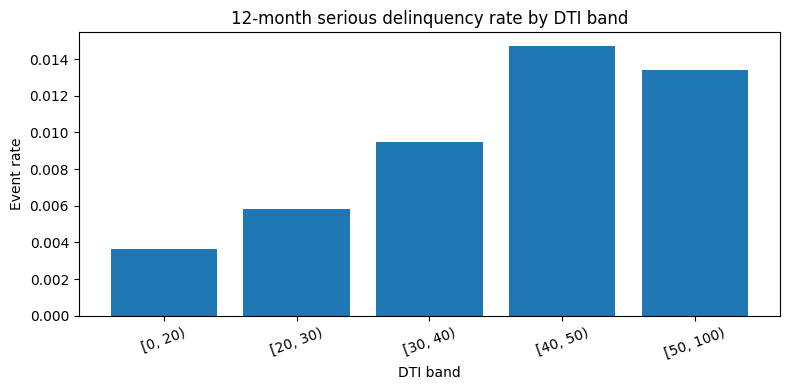

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(dti_risk["dti"].astype(str), dti_risk["event_rate"])
plt.xticks(rotation=20)
plt.xlabel("DTI band")
plt.ylabel("Event rate")
plt.title("12-month serious delinquency rate by DTI band")
plt.tight_layout()
plt.show()

The delinquency rate generally increases as debt-to-income rises, which is directionally consistent with affordability-driven credit risk. Risk rises steadily from the lowest DTI bands up to the 40–50 range, after which the highest band remains elevated but does not increase further. This suggests that DTI is a meaningful origination-stage risk indicator, even if the relationship is not perfectly monotonic at the upper end.

## 16. Build a correlation matrix for key numeric variables

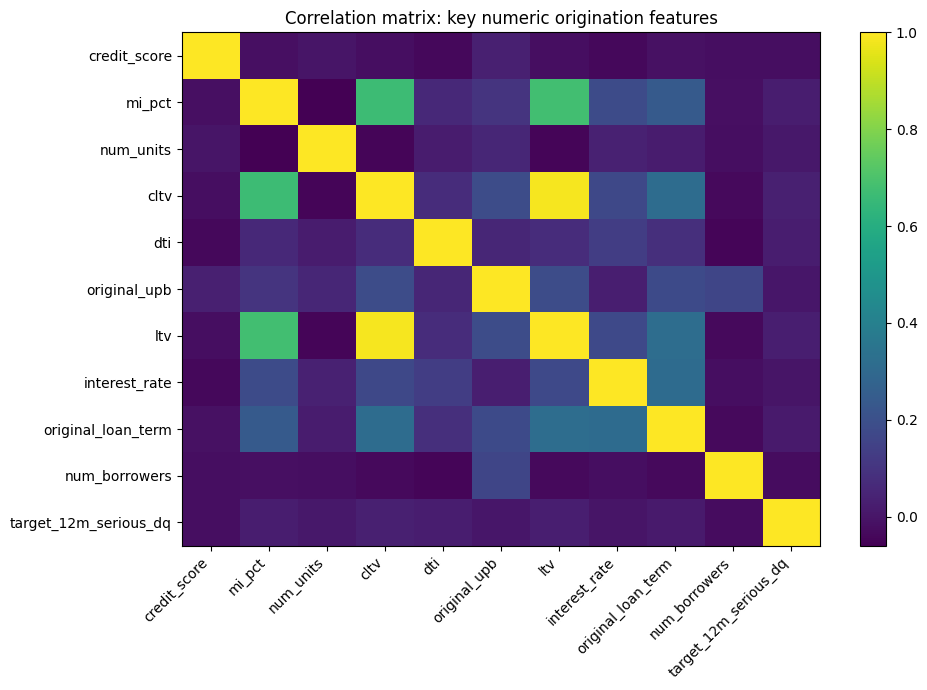

In [15]:
corr_features = [
    "credit_score",
    "mi_pct",
    "num_units",
    "cltv",
    "dti",
    "original_upb",
    "ltv",
    "interest_rate",
    "original_loan_term",
    "num_borrowers",
    "target_12m_serious_dq"
]

corr_matrix = modeling_base[corr_features].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
im = plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation matrix: key numeric origination features")
plt.colorbar(im)
plt.tight_layout()
plt.show()

The correlation matrix highlights where numeric origination variables overlap and where they contribute more distinct information. As expected in mortgage data, LTV and CLTV show extremely strong correlation, suggesting potential redundancy if both are used without additional feature selection logic. Most other pairwise relationships are modest, and the target shows only weak linear correlation with individual variables, which is normal in a low-event credit-risk setting. This chart is most useful for identifying redundancy and guiding feature selection rather than for making causal interpretations.

## 17. Save visual EDA support tables

In [16]:
corr_matrix.to_csv(TABLES / "eda_correlation_matrix_numeric.csv")
event_rate_by_vintage.to_csv(TABLES / "eda_event_rate_by_vintage.csv", index=False)
credit_score_risk.to_csv(TABLES / "eda_credit_score_risk.csv", index=False)
ltv_plot.to_csv(TABLES / "eda_ltv_risk_filtered.csv", index=False)
dti_risk.to_csv(TABLES / "eda_dti_risk.csv", index=False)

print(TABLES / "eda_correlation_matrix_numeric.csv")
print(TABLES / "eda_event_rate_by_vintage.csv")
print(TABLES / "eda_credit_score_risk.csv")
print(TABLES / "eda_ltv_risk_filtered.csv")
print(TABLES / "eda_dti_risk.csv")

/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_correlation_matrix_numeric.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_event_rate_by_vintage.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_credit_score_risk.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_ltv_risk_filtered.csv
/content/drive/MyDrive/freddie_mac_risk_project/outputs/tables/eda_dti_risk.csv


## Conclusion

The visual EDA confirms that the modeling base behaves consistently with mortgage underwriting intuition. Serious delinquency is a rare event, varies across origination vintages, and moves in the expected direction across core variables such as credit score, LTV, and DTI. The correlation matrix also highlights that some numeric features, especially LTV and CLTV, are strongly overlapping, which will be relevant for later feature selection and model design.